In [ ]:
# --- Colab auth + GCP project ---
from google.colab import auth
auth.authenticate_user()
!gcloud config set project master-thesis-measles -q

INFORMATION: Project 'master-thesis-measles' has no 'environment' tag set. Use either 'Production', 'Development', 'Test', or 'Staging'. Add an 'environment' tag using `gcloud resource-manager tags bindings create`.
Updated property [core/project].


In [ ]:
# ================================================
# 1) Imports and Constants
# ================================================
# %load_ext autoreload
# %autoreload 2
# %matplotlib inline

import os, re, math, glob, io, sys, pickle, json, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
os.environ['CUDA_VISIBLE_DEVICES'] = ''  # force CPU here

# -------- CONFIG: paths --------
GCS_PREFIX      = "gs://ssadata"              # change if needed
TFRECORD_GLOB   = f"{GCS_PREFIX}/*_*.tfrecord.gz"  # e.g., BF_2021_00.tfrecord.gz
LOC_WEALTH_CSV  = "../data/cluster_yeh_spec.csv"   # your merged DHS wealth+GPS CSV
LOC_DICT_PATH   = "../data/dhs_loc_dict.pkl"       # will be created if missing
INC_FOLDS_PATH  = "../data/dhs_incountry_folds.pkl"

# -------- CONFIG: imagery + labels --------
PATCH           = 255             # exported patch size
CROP            = 224             # center crop to 224x224
PIXELS          = CROP * CROP
SCALE_M         = 30              # meters/pixel for Landsat
BANDS_MS        = ["BLUE","GREEN","RED","NIR","SWIR1","SWIR2","TEMP1"]
BANDS_ALL       = BANDS_MS + ["NIGHTLIGHTS"]  # LON/LAT are metadata arrays if present
BAND_ORDER      = ["BLUE","GREEN","RED","SWIR1","SWIR2","TEMP1","NIR","NIGHTLIGHTS"]
DATASET_TAG     = "custom-DRC-spec"  # freeform label for your run

FOLDS           = ['A','B','C','D','E']
SPLITS          = ['train','val','test']

# DMSP vs VIIRS split threshold
DMSP_VIIRS_YEAR = 2012  # DMSP < 2012, VIIRS >= 2012

# TEMP1 DN→Kelvin heuristic if needed
ST10_SCALE  = 0.00341802
ST10_OFFSET = 149.0

rng = np.random.default_rng(42)


In [ ]:
# ================================================
# 2) Load data (scan TFRecords → arrays + meta)
# With progress bars and automatic saving
# ================================================
from tqdm.auto import tqdm
import pickle, os, numpy as np, tensorflow as tf

# --- CONFIG ---
SCAN_OUT_DIR = "/content"  # change if needed
PICKLE_OUT   = os.path.join(SCAN_OUT_DIR, "tfrecord_scan_records.pkl")
NPZ_OUT      = os.path.join(SCAN_OUT_DIR, "tfrecord_scan_arrays.npz")

def _as_arr(f, k):
    return np.asarray(f[k].float_list.value, dtype=np.float32) if k in f else None

def _as_int(f, k):
    if k in f and f[k].int64_list.value:
        return int(f[k].int64_list.value[0])
    if k in f and f[k].float_list.value:
        return int(f[k].float_list.value[0])
    return None

def _as_str(f, k):
    if k in f and f[k].bytes_list.value:
        return f[k].bytes_list.value[0].decode("utf-8")
    return None

def _center_crop(arr, patch=PATCH, crop=CROP):
    if arr is None or arr.size != patch * patch:
        return None
    z = arr.reshape(patch, patch)
    s = (patch - crop) // 2
    return z[s:s+crop, s:s+crop].ravel()

def _nl_center_mean(nl_arr):
    if nl_arr is None or nl_arr.size != PATCH * PATCH:
        return np.nan, np.nan
    z = nl_arr.reshape(PATCH, PATCH)
    s = (PATCH - CROP) // 2
    zc = z[s:s+CROP, s:s+CROP]
    return float(z[PATCH//2, PATCH//2]), float(zc.mean())

def iter_examples_tfrecord(tfrecord_path):
    ds = tf.data.TFRecordDataset(tfrecord_path, compression_type="GZIP")
    for raw in ds.as_numpy_iterator():
        yield tf.train.Example.FromString(raw)

def list_tfrecord_paths():
    return sorted(tf.io.gfile.glob(TFRECORD_GLOB))

# ---------- Scan with progress ----------
records = []
paths = list_tfrecord_paths()
assert len(paths) > 0, f"No TFRecords found at {TFRECORD_GLOB}"

for p in tqdm(paths, desc="TFRecord files"):
    try:
        examples = list(iter_examples_tfrecord(p))
    except Exception as e:
        print(f"Error reading {p}: {e}")
        continue
    for ex in tqdm(examples, desc=os.path.basename(p), leave=False):
        f = ex.features.feature
        country = _as_str(f, "country")
        year    = _as_int(f, "year")
        cluster = _as_int(f, "cluster_index") if "cluster_index" in f else _as_int(f, "cluster")

        band_arrays = {b: _as_arr(f, b) for b in BANDS_ALL}
        nl_center, nl_mean = _nl_center_mean(band_arrays.get("NIGHTLIGHTS"))

        records.append({
            "country": country,
            "year": year,
            "cluster": cluster,
            "nls_center": nl_center,
            "nls_mean": nl_mean,
        })

# --- Convert to arrays ---
years      = np.asarray([r["year"] for r in records], dtype=np.int32)
nls_center = np.asarray([r["nls_center"] for r in records], dtype=np.float32)
nls_mean   = np.asarray([r["nls_mean"] for r in records], dtype=np.float32)

# --- Save outputs ---
os.makedirs(SCAN_OUT_DIR, exist_ok=True)

with open(PICKLE_OUT, "wb") as f:
    pickle.dump(records, f)

np.savez_compressed(NPZ_OUT,
                    years=years,
                    nls_center=nls_center,
                    nls_mean=nls_mean)

print(f"TF examples: {len(records)} from {len(paths)} files")
print(f"Saved:\n - Pickle: {PICKLE_OUT}\n - NPZ: {NPZ_OUT}")

TFRecord files:   0%|          | 0/819 [00:00<?, ?it/s]

BF_2021_00.tfrecord.gz:   0%|          | 0/20 [00:00<?, ?it/s]

BF_2021_01.tfrecord.gz:   0%|          | 0/20 [00:00<?, ?it/s]

BF_2021_02.tfrecord.gz:   0%|          | 0/20 [00:00<?, ?it/s]

BF_2021_03.tfrecord.gz:   0%|          | 0/20 [00:00<?, ?it/s]

...

ZM_2018_24.tfrecord.gz:   0%|          | 0/20 [00:00<?, ?it/s]

ZM_2018_25.tfrecord.gz:   0%|          | 0/20 [00:00<?, ?it/s]

ZM_2018_26.tfrecord.gz:   0%|          | 0/2 [00:00<?, ?it/s]

ZM_2019_00.tfrecord.gz:   0%|          | 0/17 [00:00<?, ?it/s]

TF examples: 15992 from 819 files
Saved:
 - Pickle: /content/tfrecord_scan_records.pkl
 - NPZ: /content/tfrecord_scan_arrays.npz


In [ ]:
2.1 # ================================================
# Force-rebuild loc_dict with collision-free key
# Key = (COUNTRY_2L, YEAR, CLUSTER). No (lat,lon) collisions.
# Also prints diagnostics so you can see any drops.
# ================================================
import pandas as pd, numpy as np, pickle, tensorflow as tf

CSV = "/content/drive/My Drive/Master_Thesis/Surveys/clusters_yeh_spec.csv"
LOC_DICT_PATH = "/content/dhs_loc_dict.pkl"

# 1) Load and normalize
df = pd.read_csv(CSV, float_precision="high")
need = {"country","year","cluster","wealthpooled","lat","lon","n_households","urban"}
miss = need - set(df.columns)
if miss: raise ValueError(f"CSV missing columns: {sorted(miss)}")

df["country"] = df["country"].astype(str).str.upper().str[:2]
df["year"]    = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["cluster"] = pd.to_numeric(df["cluster"], errors="coerce").astype("Int64")

df["wealthpooled"] = pd.to_numeric(df["wealthpooled"], errors="coerce").astype(float)
df["lat"]          = pd.to_numeric(df["lat"], errors="coerce").astype(float)
df["lon"]          = pd.to_numeric(df["lon"], errors="coerce").astype(float)
df["n_households"] = pd.to_numeric(df["n_households"], errors="coerce").fillna(0).astype(int)
# urban accepts 0/1 or 'U'/'R'
if df["urban"].dtype == object:
    df["urban"] = (df["urban"].astype(str).str.upper() == "U")
else:
    df["urban"] = (pd.to_numeric(df["urban"], errors="coerce").fillna(0).astype(int) == 1)

# If svyid present, also compute survey start year
if "svyid" in df.columns:
    df["svyid_year"] = df["svyid"].astype(str).str[-4:].astype(int)
else:
    df["svyid_year"] = df["year"].astype(int)

# 2) Diagnostics before any de-dup
n_rows      = len(df)
n_uid_id    = df.dropna(subset=["country","year","cluster"]).assign(
                key=lambda x: list(zip(x["country"], x["year"].astype(int), x["cluster"].astype(int)))
             )["key"].nunique()
n_uid_llsy  = df.dropna(subset=["lat","lon","svyid_year"]).assign(
                key=lambda x: list(zip(x["lat"], x["lon"], x["svyid_year"].astype(int)))
             )["key"].nunique()

print(f"CSV rows: {n_rows}")
print(f"Unique (country,year,cluster): {n_uid_id}")
print(f"Unique (lat,lon,svyid_year):  {n_uid_llsy}")

# 3) De-dup on the true identifier so every cluster-year is kept exactly once
df_id = df.dropna(subset=["country","year","cluster","lat","lon"]).copy()
dupes = df_id.duplicated(subset=["country","year","cluster"], keep=False)
if dupes.any():
    # keep the first deterministically; report how many
    n_dupe_rows = int(dupes.sum())
    n_dupe_keys = int(df_id.loc[dupes, ["country","year","cluster"]].drop_duplicates().shape[0])
    print(f"WARNING: duplicate (country,year,cluster) rows: {n_dupe_rows} across {n_dupe_keys} keys. Keeping first occurrence.")
df_id = df_id.drop_duplicates(subset=["country","year","cluster"], keep="first")

# 4) Build loc_dict keyed by identifiers (no collisions)
loc_dict = {}
for _, r in df_id.iterrows():
    key = (str(r["country"]), int(r["year"]), int(r["cluster"]))
    loc_dict[key] = {
        "lat":          float(r["lat"]),
        "lon":          float(r["lon"]),
        "country":      str(r["country"]),
        "year":         int(r["year"]),                 # calendar year
        "cluster":      int(r["cluster"]),
        "country_year": f"{str(r['country'])}_{int(r['svyid_year'])}",  # surveyID-like tag
        "svyid_year":   int(r["svyid_year"]),
        "households":   int(r["n_households"]),
        "urban":        bool(r["urban"]),
        "wealthpooled": float(r["wealthpooled"]),
    }

# 5) Overwrite pickle to avoid stale file
with tf.io.gfile.GFile(LOC_DICT_PATH, "wb") as f:
    pickle.dump(loc_dict, f)

print(f"loc_dict entries (identifier-keyed): {len(loc_dict)}")
assert len(loc_dict) == df_id[["country","year","cluster"]].drop_duplicates().shape[0], "Mismatch building loc_dict"

CSV rows: 15992
Unique (country,year,cluster): 15992
Unique (lat,lon,svyid_year):  15992
loc_dict entries (identifier-keyed): 15992


In [ ]:
# ================================================
# 2.2) Combine to one DataFrame by (country, year, cluster)
# No TFRecord reread. Uses:
#  - PICKLE_OUT: list of dicts with 'country','year','cluster' (order = scan order)
#  - NPZ_OUT: arrays 'nls_center','nls_mean' aligned to records
#  - LOC_DICT_PATH: identifier-keyed dict with lat/lon/wealth/urban/households/svyid_year
# Produces df with all rows and saves CSV/Parquet.
# ================================================
import os, pickle, numpy as np, pandas as pd, tensorflow as tf

PICKLE_OUT    = "/content/tfrecord_scan_records.pkl"
NPZ_OUT       = "/content/tfrecord_scan_arrays.npz"
LOC_DICT_PATH = "/content/dhs_loc_dict.pkl"
OUT_CSV       = "/content/dhs_combined_df.csv"
OUT_PQ        = "/content/dhs_combined_df.parquet"

# --- Load records (meta) and arrays (NL) ---
with tf.io.gfile.GFile(PICKLE_OUT, "rb") as f:
    records = pickle.load(f)
npz = np.load(NPZ_OUT)
nls_center = np.asarray(npz["nls_center"], dtype=np.float32)
nls_mean   = np.asarray(npz["nls_mean"],   dtype=np.float32)

tf_df = pd.DataFrame(records)
need_cols = {"country","year","cluster"}
if not need_cols.issubset(tf_df.columns):
    raise ValueError(f"{PICKLE_OUT} missing columns: {sorted(need_cols - set(tf_df.columns))}")

N = len(tf_df)
if not (len(nls_center) == len(nls_mean) == N):
    raise AssertionError("NPZ arrays not aligned with records length")

# Normalize identifier fields and add row_id to preserve order
tf_df["country"] = tf_df["country"].astype(str).str.upper().str[:2]
tf_df["year"]    = pd.to_numeric(tf_df["year"], errors="coerce").astype(int)
tf_df["cluster"] = pd.to_numeric(tf_df["cluster"], errors="coerce").astype(int)
tf_df["row_id"]  = np.arange(N, dtype=np.int64)
tf_df["key"]     = list(zip(tf_df["country"], tf_df["year"], tf_df["cluster"]))

# Attach NL arrays by the same order as records
tf_df["nl_center"] = nls_center
tf_df["nl_mean"]   = nls_mean

# --- Load loc_dict (identifier-keyed) and convert to DataFrame for merge ---
with tf.io.gfile.GFile(LOC_DICT_PATH, "rb") as f:
    loc_dict = pickle.load(f)

ldf = pd.DataFrame(
    [{"country":k[0], "year":k[1], "cluster":k[2], **v} for k, v in loc_dict.items()]
)
ldf["country"] = ldf["country"].astype(str).str.upper().str[:2]
ldf["year"]    = pd.to_numeric(ldf["year"], errors="coerce").astype(int)
ldf["cluster"] = pd.to_numeric(ldf["cluster"], errors="coerce").astype(int)
ldf["key"]     = list(zip(ldf["country"], ldf["year"], ldf["cluster"]))

# --- One-to-one identifier merge (keeps ALL survey-years even with same lat/lon) ---
merged = tf_df.merge(ldf[["key","lat","lon","urban","households","wealthpooled","svyid_year","country_year"]],
                     on="key", how="left", validate="one_to_one")

if merged["lat"].isna().any():
    missing = int(merged["lat"].isna().sum())
    raise AssertionError(f"{missing} TF examples had no match in loc_dict by (country,year,cluster)")

# As in the reference: use surveyID year in the 'year' column
year_for_df = pd.to_numeric(merged["svyid_year"], errors="coerce").astype(int)

# --- Final DataFrame in the expected column order (urban as 0/1) ---
# merged['urban'] may be bool or {0,1}. Force 0/1.
urban01 = merged["urban"].astype(int)

df = pd.DataFrame({
    "lat":          merged["lat"].astype(float),
    "lon":          merged["lon"].astype(float),
    "wealthpooled": merged["wealthpooled"].astype(float),
    "country":      merged["country"].astype(str),
    "year":         year_for_df.astype(int),
    "urban":        urban01,                     # 0/1
    "nl_mean":      merged["nl_mean"].astype(float),
    "nl_center":    merged["nl_center"].astype(float),
    "households":   merged["households"].astype(int),
})

with pd.option_context("display.max_rows", 4):
    display(df)

print(f"Combined rows: {len(df)} "
      f"| distinct (country,year,cluster): {merged[['country','year','cluster']].drop_duplicates().shape[0]}")

# --- Save outputs ---
df.to_csv(OUT_CSV, index=False)
df.to_parquet(OUT_PQ, index=False)
print("Saved:")
print(" - CSV:", OUT_CSV)
print(" - Parquet:", OUT_PQ)

,lat,lon,wealthpooled,country,year,urban,nl_mean,nl_center,households
0,13.102978,-4.228226,-0.765235,BF,2021,0,0.314703,0.305,26
1,12.598484,-4.173245,-0.805675,BF,2021,0,0.300477,0.305,26
...,...,...,...,...,...,...,...,...,...
15990,-13.645926,32.649326,1.766822,ZM,2019,1,6.128901,11.795,20
15991,-15.385065,27.388687,-0.495971,ZM,2019,0,0.178126,0.180,24


Combined rows: 15992 | distinct (country,year,cluster): 15992
Saved:
 - CSV: /content/dhs_combined_df.csv
 - Parquet: /content/dhs_combined_df.parquet


Lat. min: -30.533213, max: 25.422785
Lon. min: -17.485937, max: 50.360668
maximum side_lat: 0.060570
maximum side_lon: 0.070321


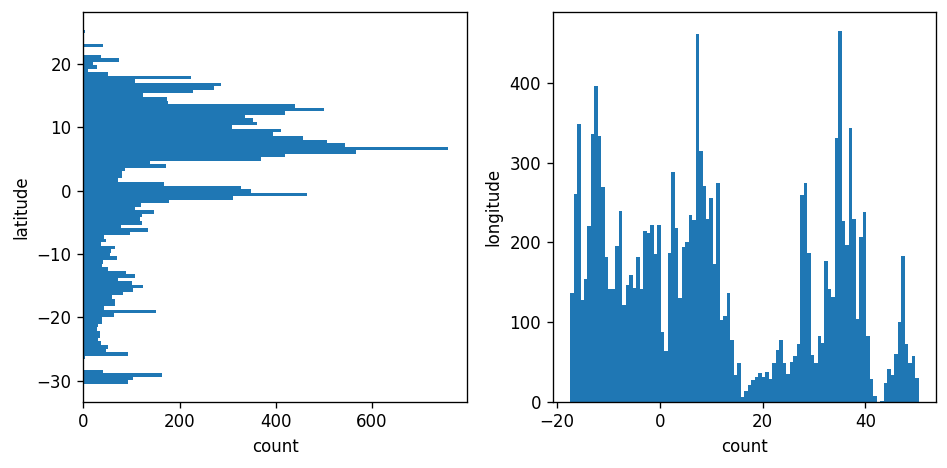

In [ ]:
# ================================================
# 3) Locations
# 3.1) Basic Location Stats + hist
# ================================================
RADIUS_EARTH = 6356.7523  # km, polar radius

def get_lon_for_distance(lat, d_km):
    lat_r = np.abs(lat) * np.pi / 180.0
    r = RADIUS_EARTH * np.cos(lat_r)
    lon = d_km / r
    return lon * 180.0 / np.pi

def get_lat_for_distance(d_km):
    lat = d_km / RADIUS_EARTH
    return lat * 180.0 / np.pi

def print_loc_stats(locs):
    min_lat, min_lon = np.min(locs, axis=0)
    max_lat, max_lon = np.max(locs, axis=0)
    print(f'Lat. min: {min_lat:.6f}, max: {max_lat:.6f}')
    print(f'Lon. min: {min_lon:.6f}, max: {max_lon:.6f}')
    side_km = CROP * SCALE_M / 1000.0
    far_lat = max(abs(min_lat), abs(max_lat))
    side_lat = get_lat_for_distance(side_km)
    side_lon = get_lon_for_distance(far_lat, side_km)
    print(f'maximum side_lat: {side_lat:.6f}')
    print(f'maximum side_lon: {side_lon:.6f}')

def plot_locs_histogram(locs):
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=[8, 4])
    axs[0].hist(locs[:, 0], bins=100, orientation='horizontal')
    axs[0].set(xlabel='count', ylabel='latitude')
    axs[1].hist(locs[:, 1], bins=100, orientation='vertical')
    axs[1].set(xlabel='count', ylabel='longitude')
    fig.tight_layout(); plt.show()

print_loc_stats(locs)
plot_locs_histogram(locs)


In [ ]:
# ================================================
# 4) Create Data Splits
# 4.1) country_indices and country_labels
# ================================================
COUNTRIES = np.array(sorted(df['country'].unique()))
country_indices = defaultdict(list)
country_labels  = np.zeros(len(df), dtype=np.int32)

for i, (lat, lon) in enumerate(zip(df['lat'].values, df['lon'].values)):
    country = df['country'].iloc[i]
    country_indices[country].append(i)

for i, country in enumerate(COUNTRIES):
    idxs = np.asarray(country_indices[country], dtype=np.int64)
    country_indices[country] = idxs
    country_labels[idxs] = i


{'A': {'test': 4838, 'train': 7824, 'val': 3330},
 'B': {'test': 3330, 'train': 9862, 'val': 2800},
 'C': {'test': 2800, 'train': 10430, 'val': 2762},
 'D': {'test': 2762, 'train': 10968, 'val': 2262},
 'E': {'test': 2262, 'train': 8892, 'val': 4838}}
Saved map: /content/africa_ooc_test_folds.png


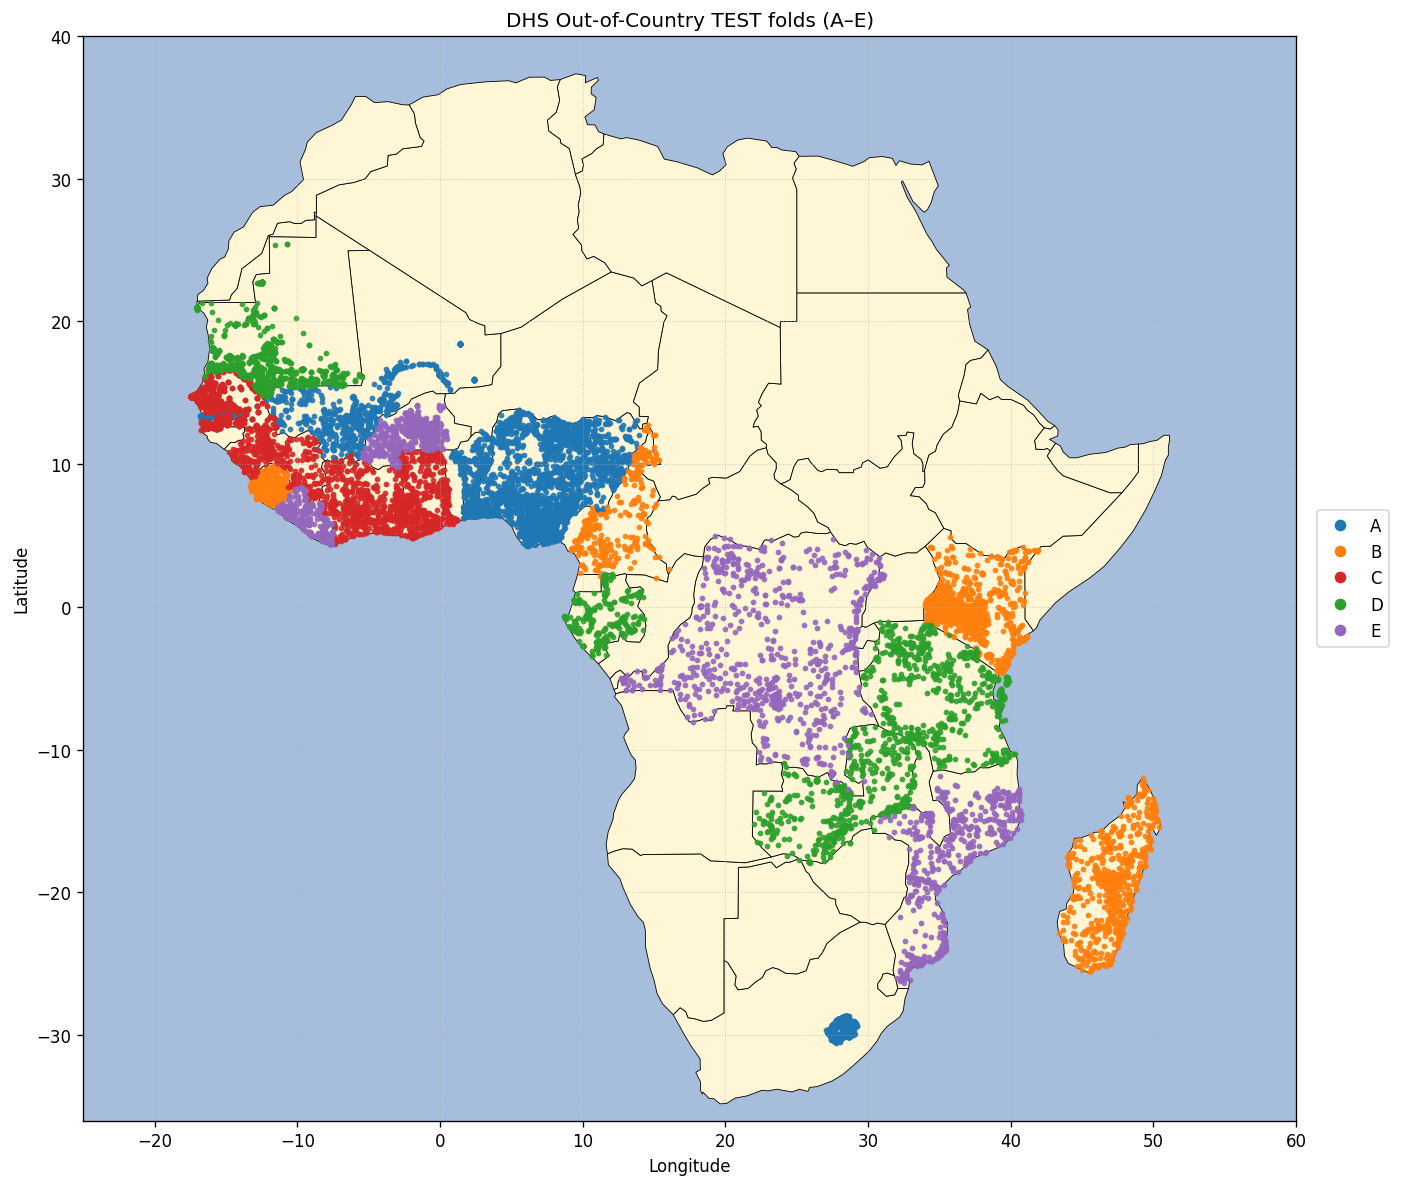

In [ ]:
# ================================================
# 4.2) OOC splits (balanced by country across 5 folds) + Africa map of TEST folds
# ================================================
from pprint import pprint
import numpy as np

def make_ooc_folds_balanced(country_indices, folds=FOLDS):
    # round-robin assign countries to folds by size desc
    order = sorted(country_indices.items(), key=lambda kv: len(kv[1]), reverse=True)
    fold_countries = {f: [] for f in folds}
    for i, (cc, _) in enumerate(order):
        fold_countries[folds[i % len(folds)]].append(cc)

    ooc = {f: {s: None for s in SPLITS} for f in folds}
    for f in folds:
        test_countries  = fold_countries[f]
        val_countries   = fold_countries[folds[(folds.index(f)+1) % len(folds)]]
        train_countries = [c for c in COUNTRIES if c not in set(test_countries + val_countries)]
        ooc[f]['test']  = np.sort(np.concatenate([country_indices[c] for c in test_countries]))  if test_countries  else np.array([], dtype=int)
        ooc[f]['val']   = np.sort(np.concatenate([country_indices[c] for c in val_countries]))   if val_countries   else np.array([], dtype=int)
        ooc[f]['train'] = np.sort(np.concatenate([country_indices[c] for c in train_countries])) if train_countries else np.array([], dtype=int)
    return ooc

ooc_folds = make_ooc_folds_balanced(country_indices)
pprint({f:{s:len(ooc_folds[f][s]) for s in SPLITS} for f in FOLDS})

# ----------------- Africa map of TEST folds -----------------
!pip -q install geopandas shapely pyproj

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OUT_PNG = "/content/africa_ooc_test_folds.png"

# Load Natural Earth countries directly (GeoPandas ≥1.0 removed gpd.datasets)
NE_URL = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world  = gpd.read_file(NE_URL)
africa = world[world["CONTINENT"] == "Africa"].to_crs("EPSG:4326")

# Fold colors
FOLD_COLORS = {
    "A": "#1f77b4",  # blue
    "B": "#ff7f0e",  # orange
    "C": "#d62728",  # red
    "D": "#2ca02c",  # green
    "E": "#9467bd",  # purple
}

# Prepare coordinate array aligned with df indices
LOCS = df[["lat","lon"]].to_numpy(dtype=float)

# Prepare plot
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor("#a6bddb")  # ocean
africa.plot(ax=ax, color="#fff6d5", edgecolor="black", linewidth=0.5)

# Plot TEST points per fold
for f in FOLDS:
    idx = ooc_folds[f]["test"].astype(int)
    valid = (idx >= 0) & (idx < len(LOCS))
    idx = idx[valid]
    if idx.size == 0:
        continue
    ax.scatter(LOCS[idx, 1], LOCS[idx, 0], s=6, c=FOLD_COLORS[f], label=f, alpha=0.85)

# Legend (vertical, outside right)
handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=FOLD_COLORS[f],
                  markersize=8, linestyle='') for f in FOLDS]
ax.legend(handles, FOLDS, title="", loc="center left", bbox_to_anchor=(1.01, 0.5))

# Gridlines and bounds
ax.set_xlim(-25, 55); ax.set_ylim(-36, 38)
ax.set_xticks(np.arange(-20, 61, 10)); ax.set_yticks(np.arange(-30, 41, 10))
ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.6)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("DHS Out-of-Country TEST folds (A–E)")

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=200)
print("Saved map:", OUT_PNG)
plt.show()

num clusters: 1686
max cluster size: 465
num outliers: 4534
A B 0.09296192651028194
A C 0.09347474249763889
A D 0.09289139899904468
A E 0.09317927590714901
B C 0.09331580993373277
B D 0.09313804325301299
B E 0.09304877521735444
C D 0.09290334702747037
C E 0.09312206268624673
D E 0.09293582863997674
{'A': {'test': 3199, 'train': 9594, 'val': 3199},
 'B': {'test': 3199, 'train': 9595, 'val': 3198},
 'C': {'test': 3198, 'train': 9596, 'val': 3198},
 'D': {'test': 3198, 'train': 9596, 'val': 3198},
 'E': {'test': 3198, 'train': 9595, 'val': 3199}}
incountry MIN_DIST deg: 0.09281024778521978
Saved map: /content/africa_incountry_test_folds.png


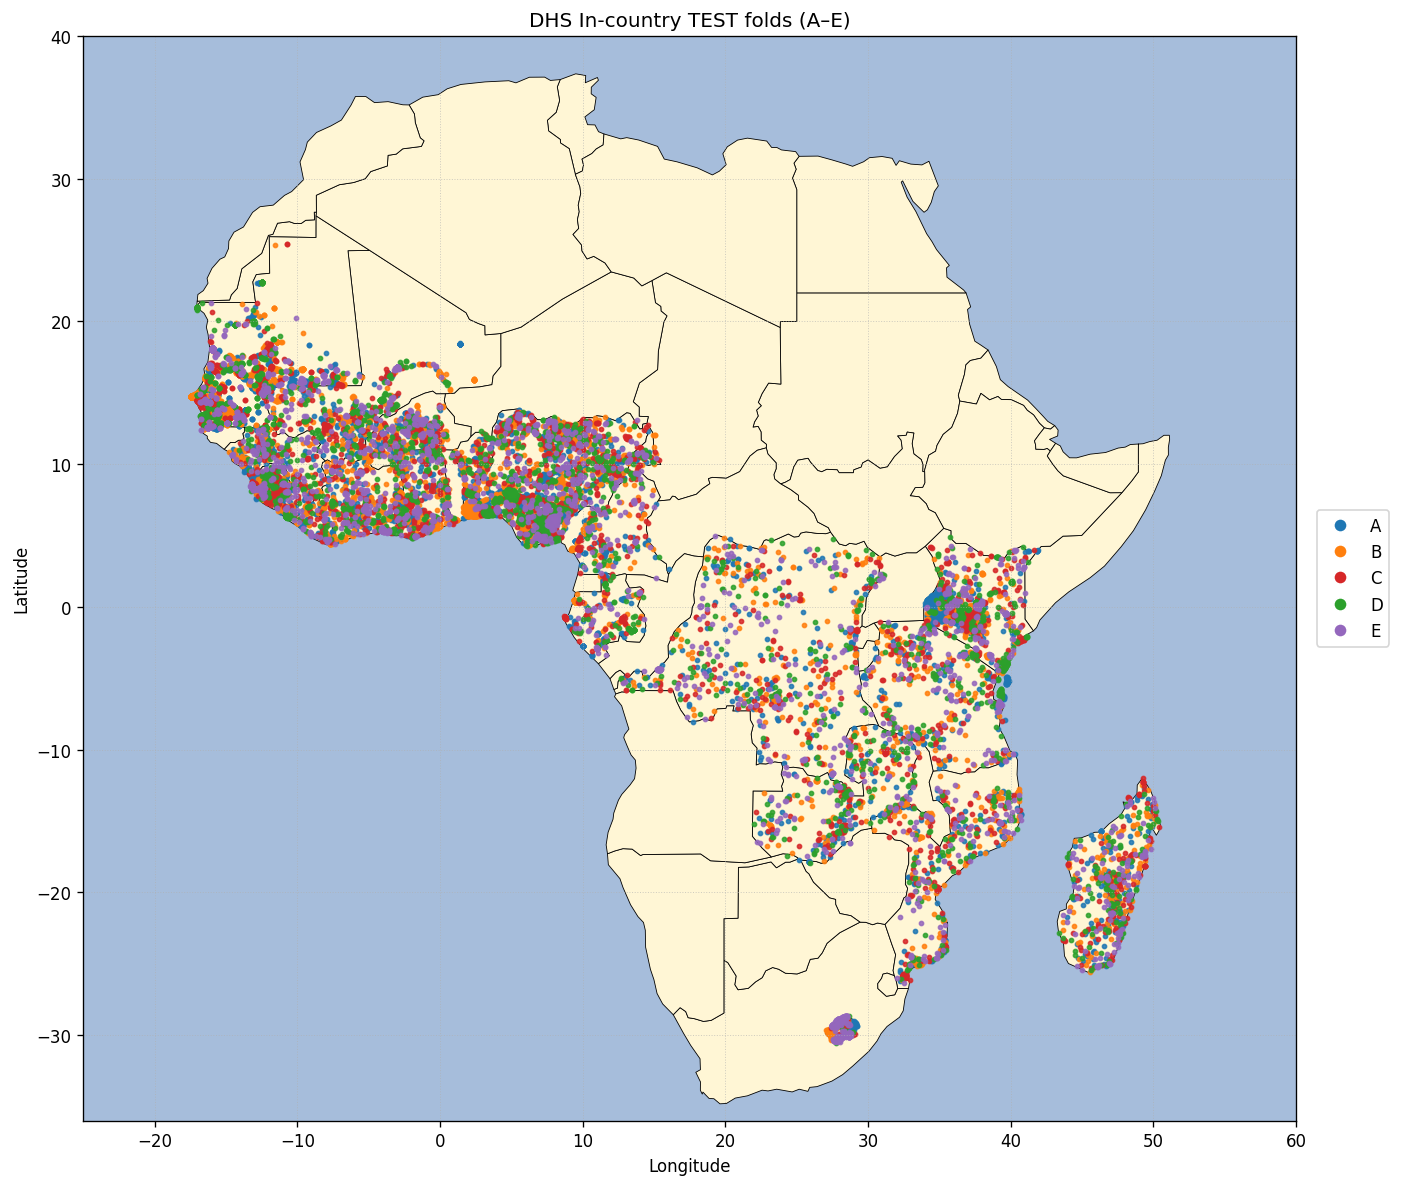

In [ ]:
# ================================================
# 4.3) In-country splits (Yeh et al. style) + Africa map of TEST folds
# Self-contained: defines create_folds/verify_folds if missing,
# uses df coordinates, and avoids deprecated gpd.datasets.
# ================================================
import math, pickle, numpy as np, pandas as pd, tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- inputs ----------
FOLDS = ['A','B','C','D','E']
SPLITS = ['train','val','test']
INC_FOLDS_PATH = "/content/dhs_incountry_folds.pkl"

# Coordinates aligned to df indices
LOCS = df[["lat","lon"]].to_numpy(dtype=float)

# ---------- helpers for lat/lon degree spans ----------
RADIUS_EARTH = 6356.7523  # km, polar radius
def get_lat_for_distance_km(d):
    return (d / RADIUS_EARTH) * 180.0 / np.pi
def get_lon_for_distance_km(lat_deg, d):
    r = RADIUS_EARTH * np.cos(np.abs(lat_deg) * np.pi / 180.0)
    return (d / r) * 180.0 / np.pi

# ---------- define create_folds / verify_folds if not present ----------
try:
    create_folds  # noqa: F401
    verify_folds  # noqa: F401
except NameError:
    from collections import defaultdict
    import itertools, scipy.spatial
    from sklearn.cluster import dbscan as _dbscan

    def create_folds(locs, min_dist, dist_metric, fold_names, verbose=True, plot_largest_clusters=0):
        locs = np.asarray(locs, dtype=float)
        # map unique locs to indices
        locs_to_indices = defaultdict(list)
        for i, loc in enumerate(locs):
            locs_to_indices[tuple(loc)].append(i)
        uniq = np.unique(locs, axis=0)
        _, labels = _dbscan(X=uniq, eps=min_dist, min_samples=2, metric=dist_metric)

        # cluster -> indices
        clusters = defaultdict(list)
        neg = -1
        for u, c in zip(uniq, labels):
            idxs = locs_to_indices[tuple(u)]
            if c < 0:
                c = neg
                neg -= 1
            clusters[c].extend(idxs)

        # sort clusters by size desc
        ordered = sorted(clusters.keys(), key=lambda c: -len(clusters[c]))
        folds = {f: [] for f in fold_names}
        for c in ordered:
            f = min(folds, key=lambda k: len(folds[k]))
            folds[f].extend(clusters[c])
        for f in folds:
            folds[f] = np.sort(np.asarray(folds[f], dtype=np.int64))
        if verbose:
            sizes = [len(clusters[c]) for c in ordered if c >= 0]
            print("num clusters:", sum(1 for c in clusters if c >= 0))
            print("max cluster size:", max(sizes) if sizes else 1)
            print("num outliers:", sum(1 for c in clusters if c < 0))
        return locs_to_indices, folds

    def verify_folds(folds, locs, min_dist, dist_metric, max_index=None):
        for f, idxs in folds.items():
            assert np.all(np.diff(idxs) >= 0)
        if max_index is not None:
            all_idx = np.sort(np.concatenate(list(folds.values())))
            assert np.array_equal(all_idx, np.arange(max_index))
        for a, b in itertools.combinations(folds.keys(), 2):
            da = locs[folds[a]]
            db = locs[folds[b]]
            d = scipy.spatial.distance.cdist(da, db, metric=dist_metric)
            assert np.min(d) > min_dist
            print(a, b, np.min(d))

# ---------- distance threshold (diagonal of 224×224 @ 30 m/px) ----------
side_km = 224 * 30 / 1000.0
far_lat = float(max(abs(LOCS[:,0].min()), abs(LOCS[:,0].max())))
side_lat = get_lat_for_distance_km(side_km)
side_lon = get_lon_for_distance_km(far_lat, side_km)
MIN_DIST = float(math.hypot(side_lat, side_lon))
DIST_METRIC = "euclidean"

# ---------- build DBSCAN-based test folds ----------
locs_to_indices, test_folds = create_folds(
    LOCS, min_dist=MIN_DIST, dist_metric=DIST_METRIC,
    fold_names=FOLDS, verbose=True, plot_largest_clusters=0
)

# verify and convert to train/val/test
verify_folds(test_folds, locs=LOCS, min_dist=MIN_DIST,
             dist_metric=DIST_METRIC, max_index=len(LOCS))

incountry_folds = {}
for i, f in enumerate(FOLDS):
    incountry_folds[f] = {}
    incountry_folds[f]['test'] = np.asarray(test_folds[f], dtype=np.int64)
    val_f = FOLDS[(i+1) % len(FOLDS)]
    incountry_folds[f]['val'] = np.asarray(test_folds[val_f], dtype=np.int64)
    train_fs = [FOLDS[(i+2)%5], FOLDS[(i+3)%5], FOLDS[(i+4)%5]]
    incountry_folds[f]['train'] = np.sort(
        np.concatenate([np.asarray(test_folds[x], dtype=np.int64) for x in train_fs])
    )

with tf.io.gfile.GFile(INC_FOLDS_PATH, "wb") as f:
    pickle.dump(incountry_folds, f)

from pprint import pprint
pprint({f: {s: len(incountry_folds[f][s]) for s in ['test','val','train']} for f in FOLDS})
print("incountry MIN_DIST deg:", MIN_DIST)

# ----------------- Africa map of TEST folds (incountry) -----------------
# Install geopandas stack if needed
!pip -q install geopandas shapely pyproj

import geopandas as gpd

OUT_PNG = "/content/africa_incountry_test_folds.png"

# Natural Earth download (works with GeoPandas ≥1.0)
NE_URL = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world  = gpd.read_file(NE_URL)
africa = world[world["CONTINENT"] == "Africa"].to_crs("EPSG:4326")

FOLD_COLORS = {"A":"#1f77b4","B":"#ff7f0e","C":"#d62728","D":"#2ca02c","E":"#9467bd"}

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor("#a6bddb")
africa.plot(ax=ax, color="#fff6d5", edgecolor="black", linewidth=0.5)

for f in FOLDS:
    idx = incountry_folds[f]["test"]
    if idx.size == 0:
        continue
    ax.scatter(LOCS[idx, 1], LOCS[idx, 0], s=6, c=FOLD_COLORS[f], label=f, alpha=0.85)

handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=FOLD_COLORS[f],
                  markersize=8, linestyle='') for f in FOLDS]
ax.legend(handles, FOLDS, loc="center left", bbox_to_anchor=(1.01, 0.5))

ax.set_xlim(-25, 55); ax.set_ylim(-36, 38)
ax.set_xticks(np.arange(-20, 61, 10)); ax.set_yticks(np.arange(-30, 41, 10))
ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.6)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("DHS In-country TEST folds (A–E)")

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=200)
print("Saved map:", OUT_PNG)
plt.show()

In [ ]:
# ================================================
# 4.4) Urban v. Rural counts by OOC folds
# ================================================
urban_mask = (df['urban'].values.astype(int) == 1)
rural_mask = ~urban_mask

def fold_ur_counts(folds):
    u, r = {}, {}
    for f, splits in folds.items():
        u[f], r[f] = {}, {}
        for s, idx in splits.items():
            idx = np.asarray(idx, dtype=np.int64)
            u[f][s] = int(urban_mask[idx].sum())
            r[f][s] = int(rural_mask[idx].sum())
        u[f]['all'] = sum(u[f][s] for s in SPLITS)
        r[f]['all'] = sum(r[f][s] for s in SPLITS)
    return u, r

uA, rA = fold_ur_counts(ooc_folds)
print("urban counts"); pprint(uA)
print("rural counts"); pprint(rA)


urban counts
{'A': {'all': 6612, 'test': 2085, 'train': 3249, 'val': 1278},
 'B': {'all': 6612, 'test': 1278, 'train': 4087, 'val': 1247},
 'C': {'all': 6612, 'test': 1247, 'train': 4143, 'val': 1222},
 'D': {'all': 6612, 'test': 1222, 'train': 4610, 'val': 780},
 'E': {'all': 6612, 'test': 780, 'train': 3747, 'val': 2085}}
rural counts
{'A': {'all': 9380, 'test': 2753, 'train': 4575, 'val': 2052},
 'B': {'all': 9380, 'test': 2052, 'train': 5775, 'val': 1553},
 'C': {'all': 9380, 'test': 1553, 'train': 6287, 'val': 1540},
 'D': {'all': 9380, 'test': 1540, 'train': 6358, 'val': 1482},
 'E': {'all': 9380, 'test': 1482, 'train': 5145, 'val': 2753}}


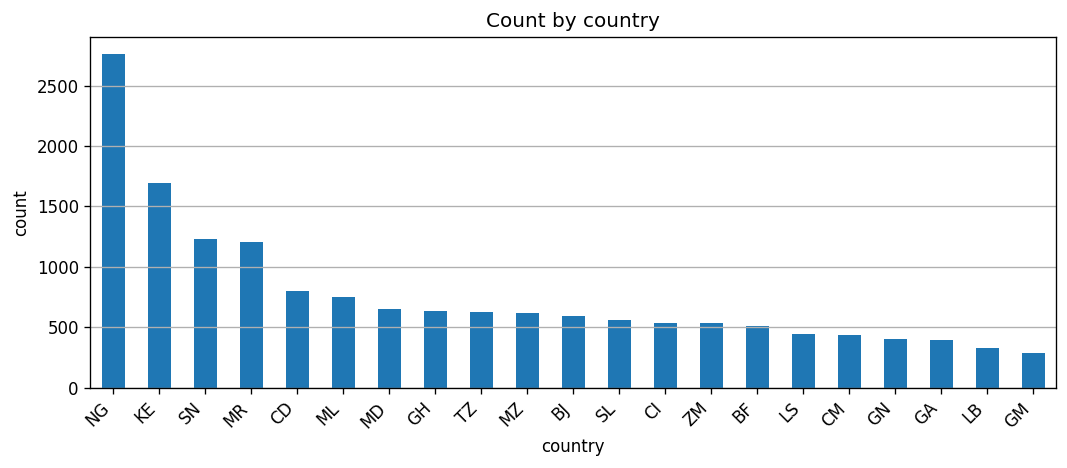

count
country year       
BF      2021    514
BJ      2017    288
        2018    309
CD      2023    617
        2024    179
CI      2021    539
CM      2018    427
        2019      5
GA      2019     34
        2020    166
        2021    192
GH      2022    549
        2023     84
GM      2019     87
        2020    197
GN      2018    401
KE      2022   1691
LB      2019    187
        2020    143
LS      2023    110
        2024    333
MD      2021    650
ML      2018    328
        2023    114
        2024    308
MR      2019    293
        2020    730
        2021    180
MZ      2022    523
        2023     99
NG      2018   1382
        2023    173
        2024   1209
SL      2019    557
SN      2017    400
        2018    214
        2019    214
        2023    399
TZ      2022    628
ZM      2018    522
        2019     17

In [ ]:
# ================================================
# 5) Data Analysis by Country
# 5.1) Size
# ================================================
def plot_countries_by_size(df):
    counts = df.groupby('country').size().sort_values(ascending=False)
    fig, ax = plt.subplots(1,1, figsize=(9,4))
    counts.plot(kind='bar', ax=ax)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylabel('count'); ax.set_title('Count by country'); ax.grid(True, axis='y')
    fig.tight_layout(); plt.show()

plot_countries_by_size(df)

with pd.option_context('display.max_rows', 200):
    display(df.groupby(['country','year']).size().rename('count').to_frame())


,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
BF,514.0,0.004042,0.736387,-1.231751,-0.561926,-0.184110,0.418515,3.031259
BJ,597.0,0.020657,0.740291,-1.261835,-0.557607,-0.180859,0.549650,2.448210
CD,796.0,-0.002704,0.855725,-0.809626,-0.462135,-0.327432,0.009635,3.747965
CI,539.0,0.010858,0.739989,-1.603834,-0.551072,0.000939,0.587728,2.019389
CM,432.0,0.000361,0.800773,-1.630068,-0.781650,0.140148,0.669901,1.691910
GA,392.0,0.001144,0.816616,-1.916151,-0.605175,0.326553,0.630460,1.290999
GH,633.0,-0.006255,0.741727,-1.609941,-0.474917,0.012504,0.522125,1.852116
GM,284.0,0.028004,0.787996,-1.533122,-0.813340,0.255652,0.708945,1.442165
GN,401.0,0.004305,0.858723,-1.242448,-0.682460,-0.376428,0.798123,1.996090


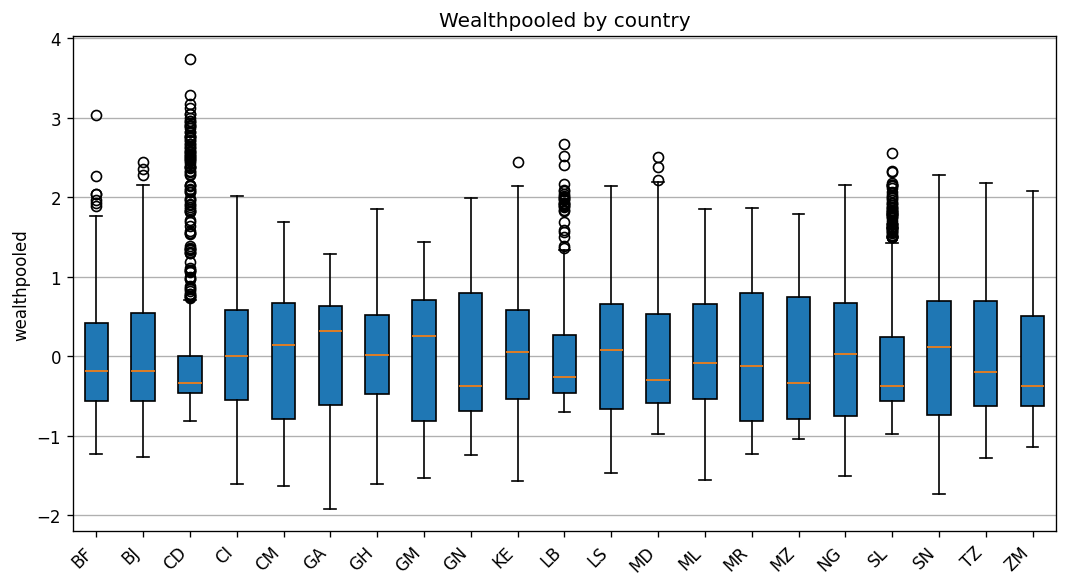

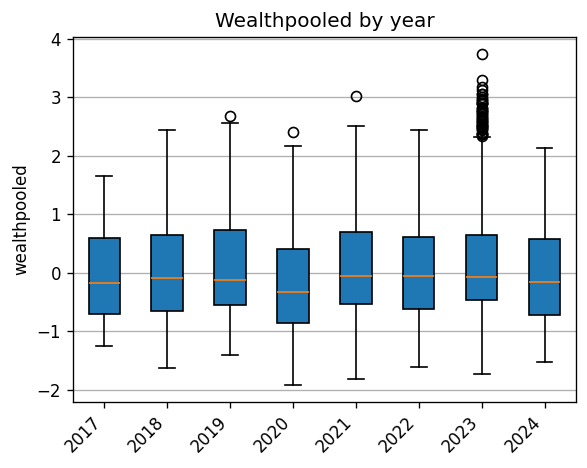

In [ ]:
# ================================================
# 5.2) Wealthpooled summary + boxplots
# ================================================
def colordisplay(d): display(d)  # placeholder for your util

df_country = df.groupby('country')['wealthpooled'].describe()
colordisplay(df_country)

def boxplot_df(df_in, y, by, figsize=(8,5), ylabel='', title='', colors=None):
    data = df_in.groupby(by)[y].apply(list)
    labels = data.index if isinstance(data.index, pd.Index) else range(len(data))
    fig, ax = plt.subplots(1,1, figsize=figsize)
    ax.boxplot(list(data), patch_artist=True)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel(ylabel or y); ax.set_title(title); ax.grid(True, axis='y')
    fig.tight_layout(); plt.show()

YEARS = sorted(df['year'].unique())
boxplot_df(df, y='wealthpooled', by='country',
           figsize=(9,5), ylabel='wealthpooled',
           title='Wealthpooled by country')

boxplot_df(df, y='wealthpooled', by='year',
           figsize=(5,4), ylabel='wealthpooled',
           title='Wealthpooled by year')


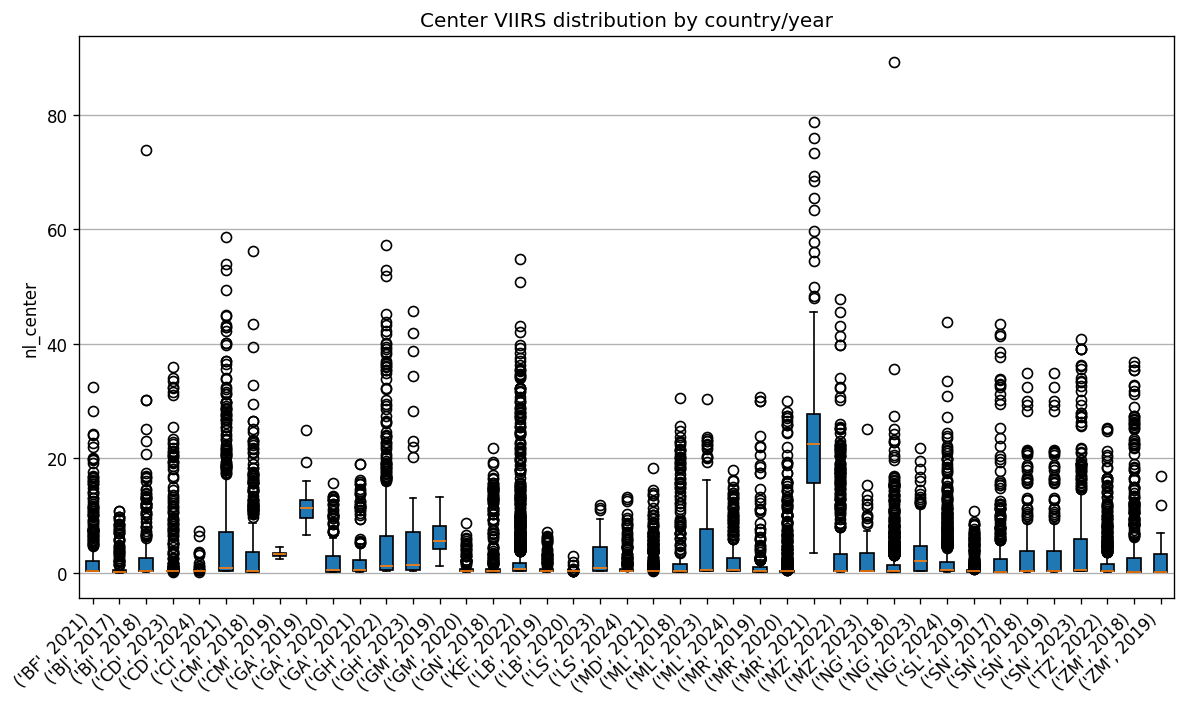

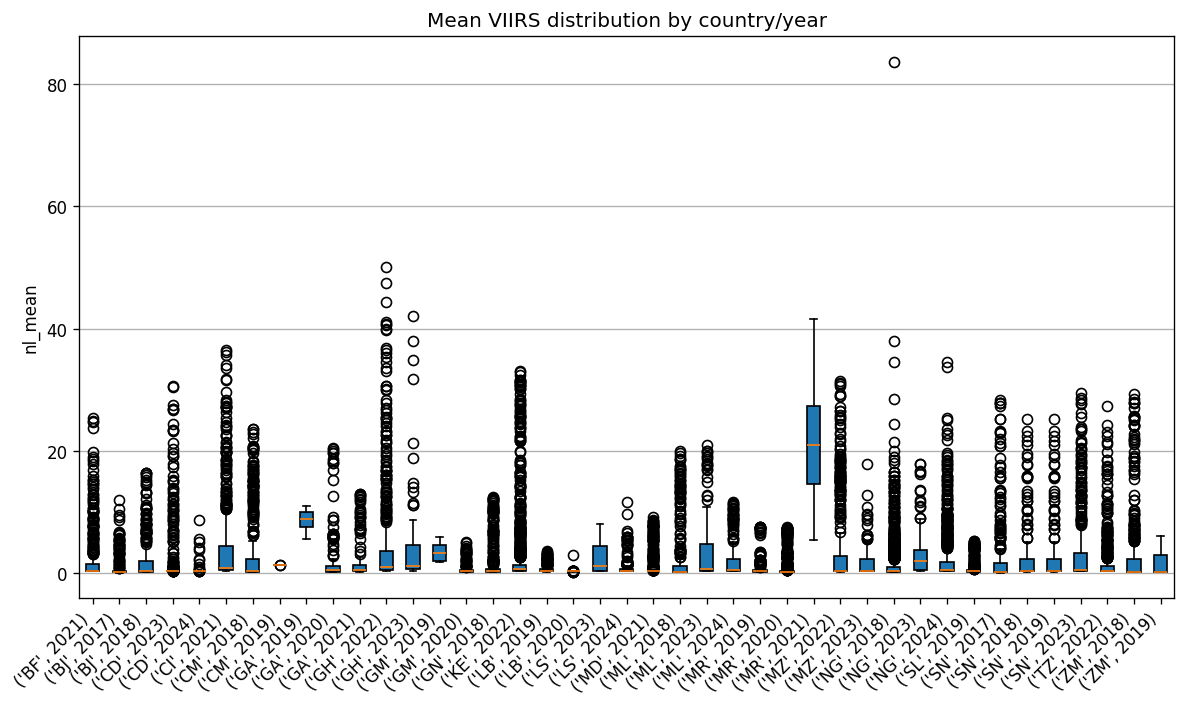

In [ ]:
# ================================================
# 5.4) Nightlights distributions (VIIRS only)
# ================================================

# All rows are VIIRS in your dataset
viirs_mask = np.ones(len(df), dtype=bool)

# --- Center ---
boxplot_df(df[viirs_mask], y='nl_center', by=['country','year'],
           figsize=(10,6), ylabel='nl_center',
           title='Center VIIRS distribution by country/year')

# --- Mean ---
boxplot_df(df[viirs_mask], y='nl_mean', by=['country','year'],
           figsize=(10,6), ylabel='nl_mean',
           title='Mean VIIRS distribution by country/year')

share households < 16: 0.09204602301150576


,count,mean,std,min,0%,1%,2%,3%,4%,5%,...,91%,92%,93%,94%,95%,96%,97%,98%,99%,max
households,15992.0,24.584542,6.281953,1.0,1.0,6.0,9.0,10.0,10.0,10.0,...,31.0,32.0,32.0,33.0,34.0,34.0,34.0,34.0,34.0,36.0


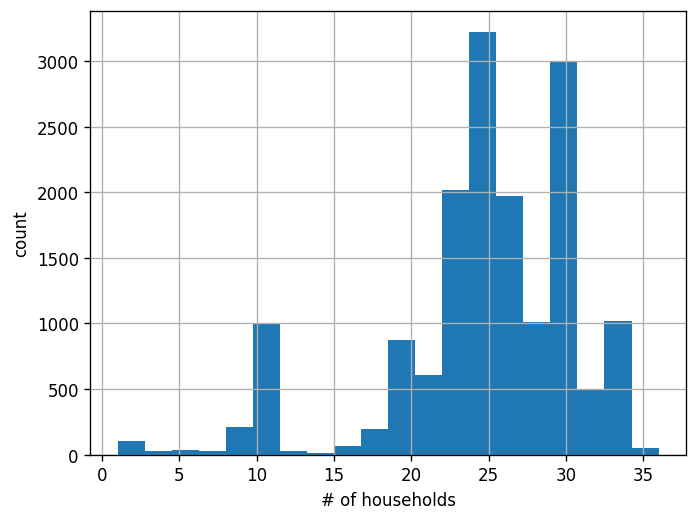

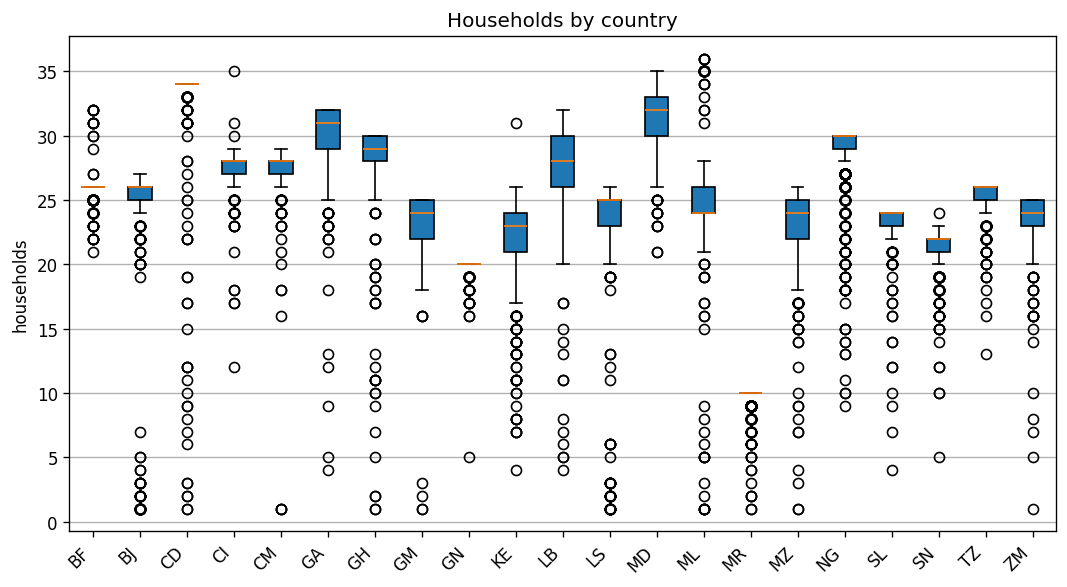

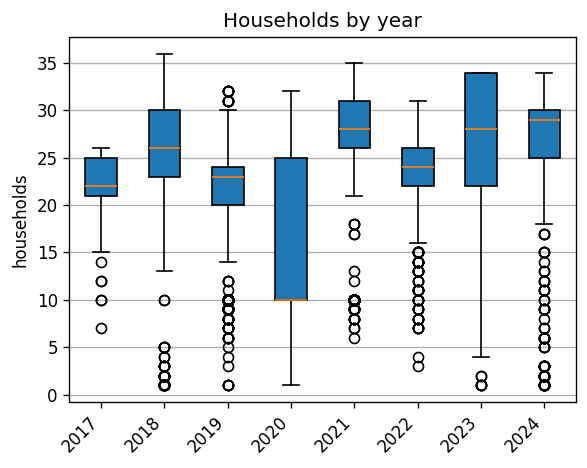

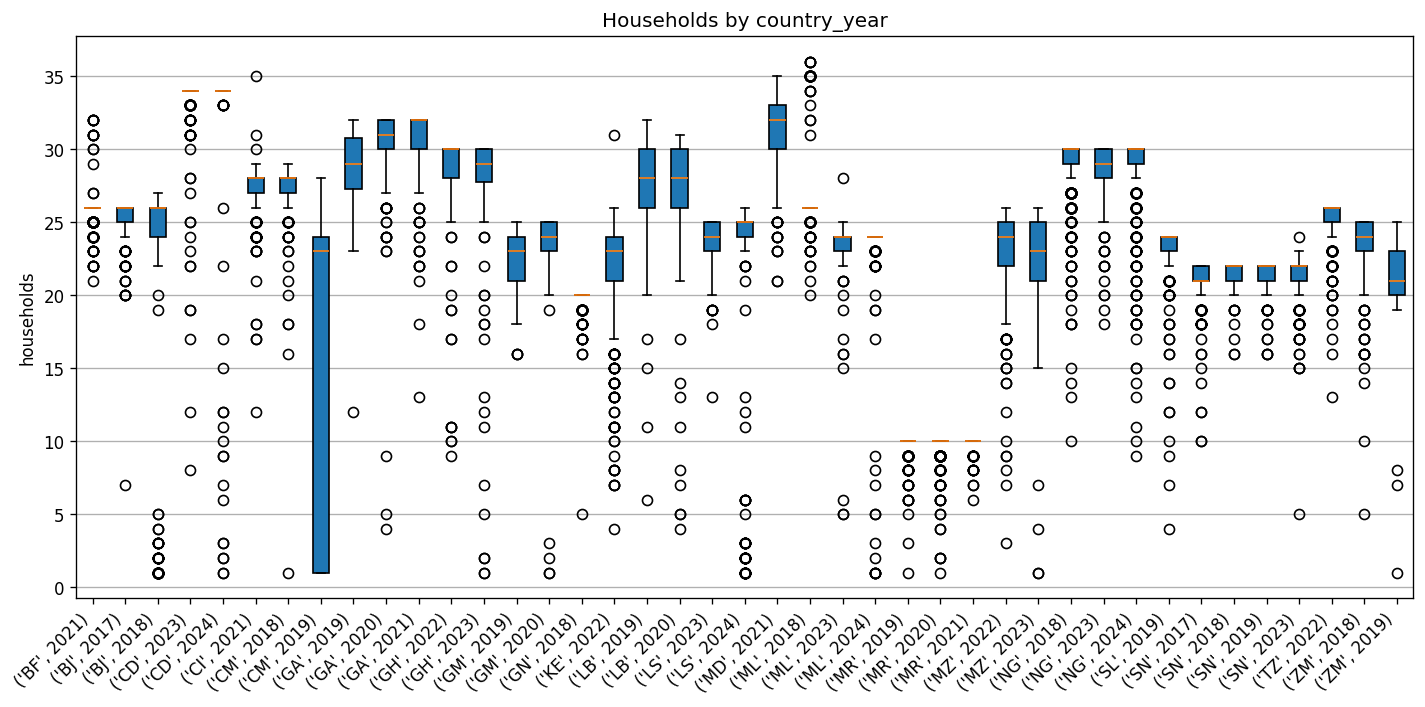

In [ ]:
# ================================================
# 5.5) Households
# ================================================
print("share households < 16:", float((df['households']<16).mean()))
ax = df['households'].plot.hist(bins=20, grid=True)
_ = ax.set(xlabel='# of households', ylabel='count')
display(df['households'].describe(percentiles=np.arange(0,1,0.01)).to_frame().T)

boxplot_df(df, y='households', by='country',
           figsize=(9,5), ylabel='households',
           title='Households by country')

boxplot_df(df, y='households', by='year',
           figsize=(5,4), ylabel='households',
           title='Households by year')

boxplot_df(df, y='households', by=['country','year'],
           figsize=(12,6), ylabel='households',
           title='Households by country_year')


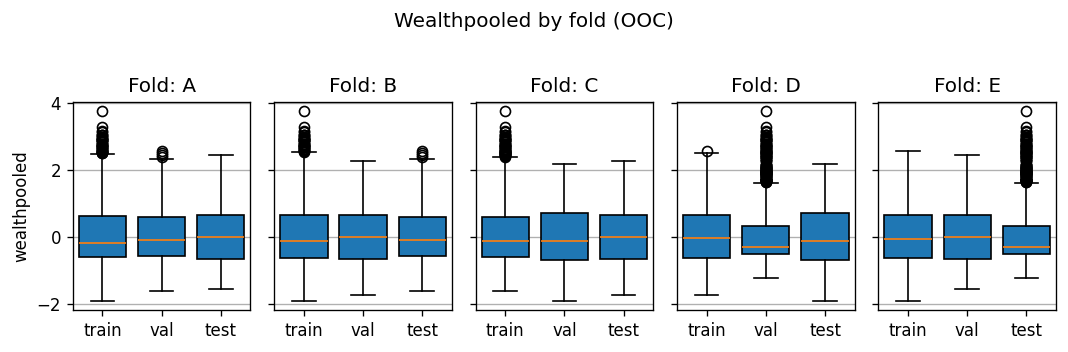

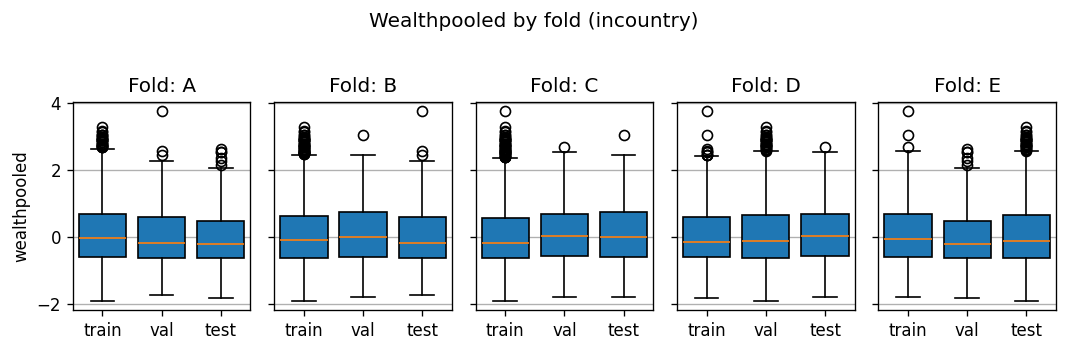

In [ ]:
# ================================================
# 6) Data Analysis by Split
# 6.1) Wealthpooled distributions by fold
# ================================================
def plot_labels_by_fold(labels, folds, title=None):
    fig, axs = plt.subplots(1,5, sharey=True, figsize=(9,2.8))
    for f, ax in zip(FOLDS, axs.flat):
        data = [labels[folds[f][split]] for split in SPLITS]
        ax.boxplot(data, patch_artist=True, widths=0.8)
        plt.setp(ax, xticks=[1,2,3], xticklabels=SPLITS)
        ax.grid(True, axis='y'); ax.set_title(f'Fold: {f}')
    axs[0].set_ylabel('wealthpooled')
    if title: fig.suptitle(title, y=1.03)
    fig.tight_layout(); plt.show()

plot_labels_by_fold(df['wealthpooled'].values, ooc_folds, title='Wealthpooled by fold (OOC)')
plot_labels_by_fold(df['wealthpooled'].values, incountry_folds, title='Wealthpooled by fold (incountry)')


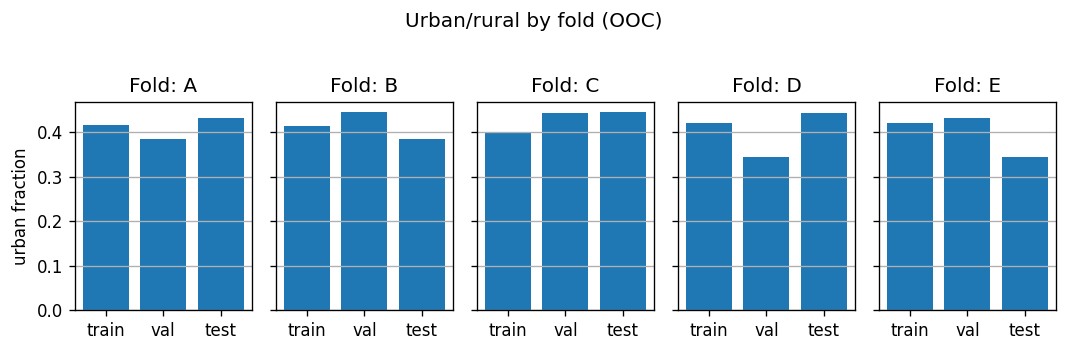

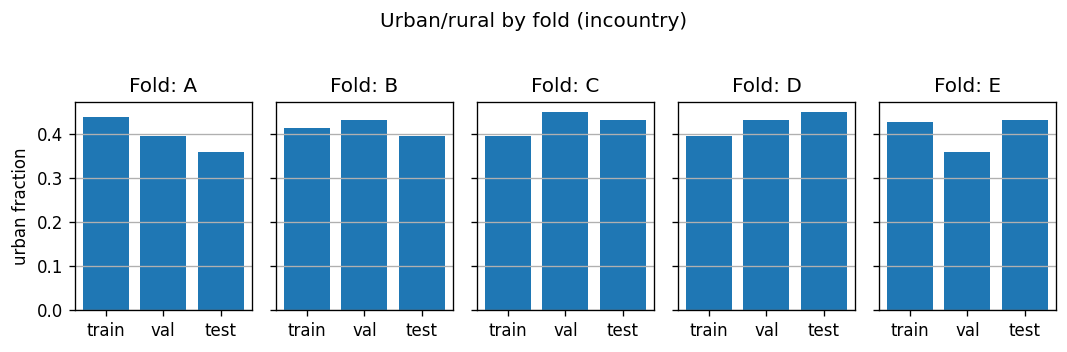

In [ ]:
# ================================================
# 6.2) Urban v. Rural by fold
# ================================================
def plot_urban_by_fold(urban, folds, title=None):
    fig, axs = plt.subplots(1,5, sharey=True, figsize=(9,2.8))
    for f, ax in zip(FOLDS, axs.flat):
        data = [urban[folds[f][split]].mean() for split in SPLITS]
        ax.bar([0,1,2], data, width=0.8)
        plt.setp(ax, xticks=[0,1,2], xticklabels=SPLITS)
        ax.grid(True, axis='y'); ax.set_title(f'Fold: {f}')
    axs[0].set_ylabel('urban fraction')
    if title: fig.suptitle(title, y=1.03)
    fig.tight_layout(); plt.show()

plot_urban_by_fold(df['urban'].values.astype(float), ooc_folds, title='Urban/rural by fold (OOC)')
plot_urban_by_fold(df['urban'].values.astype(float), incountry_folds, title='Urban/rural by fold (incountry)')


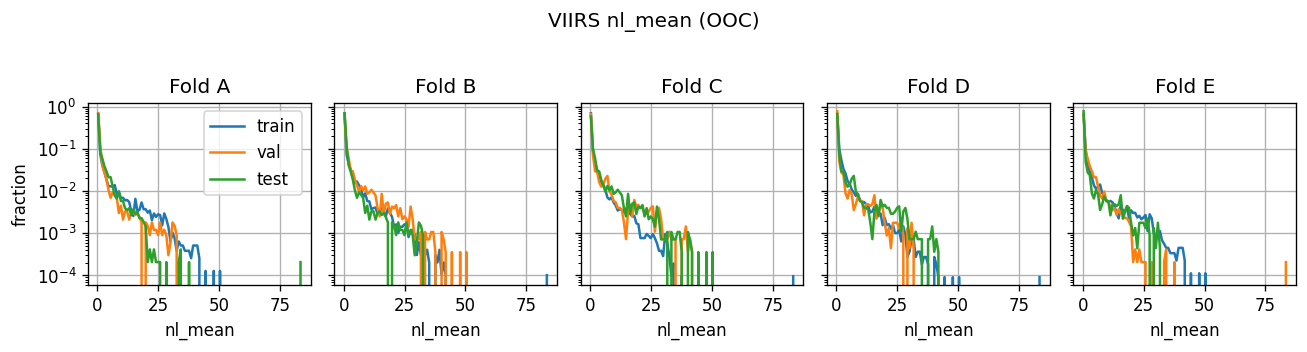

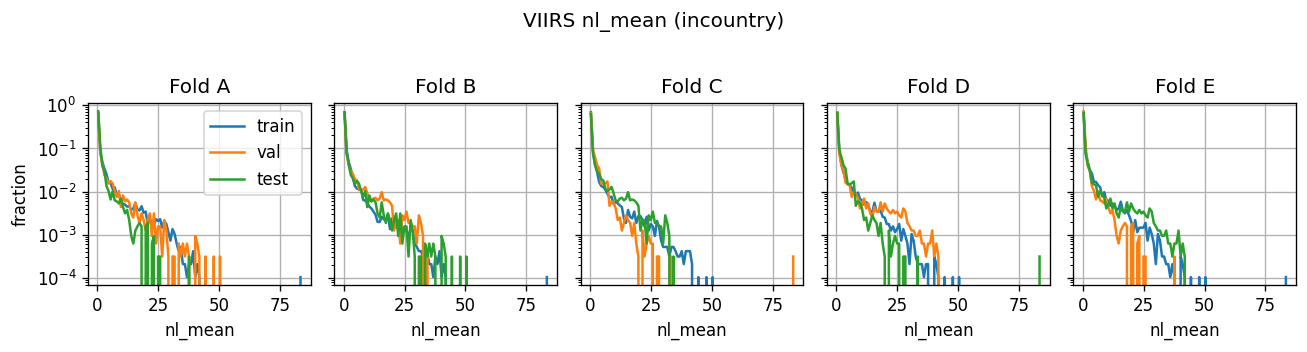

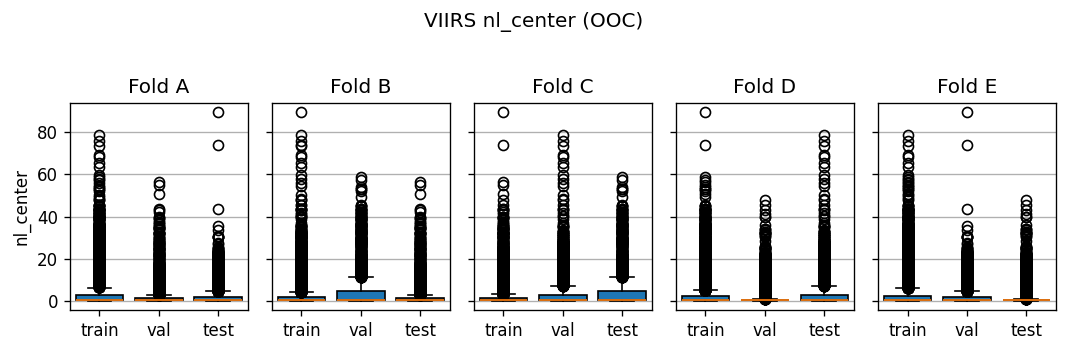

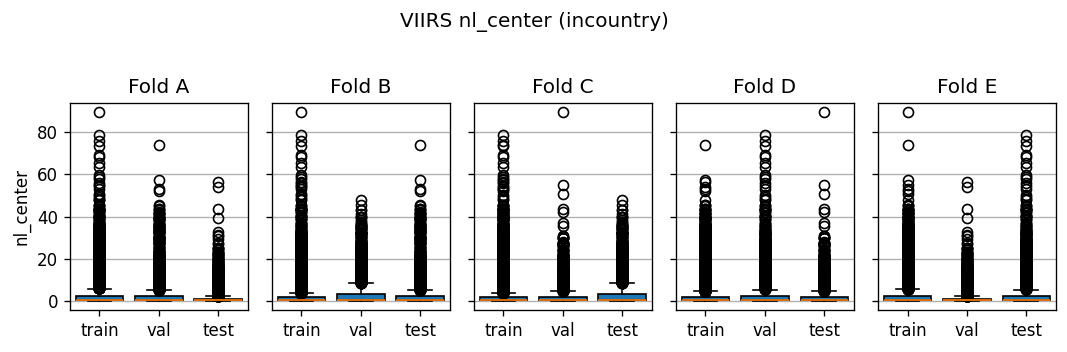

In [ ]:
# ================================================
# 6.3) Nightlights by fold (VIIRS only)
# ================================================
import numpy as np
import matplotlib.pyplot as plt

DMSP_VIIRS_YEAR = 2012  # VIIRS >= 2012

def plot_nl_by_fold_viirs(df, folds, col, title=None):
    fig, axs = plt.subplots(1, 5, sharey=True, figsize=(11, 2.8))
    bin_edges = np.linspace(df[col].min() - 0.1, df[col].max() + 0.1, 100)
    centers = np.convolve(bin_edges, [.5, .5], mode='valid')
    for f, ax in zip(FOLDS, axs.flat):
        for split in SPLITS:
            idx = folds[f][split]
            sub = df.loc[idx, [col, 'year']]
            vals = sub.loc[sub['year'] >= DMSP_VIIRS_YEAR, col].values
            if vals.size == 0:
                continue
            hist, _ = np.histogram(vals, bins=bin_edges)
            if hist.sum() > 0:
                ax.plot(centers, hist / hist.sum(), label=split)
        ax.set_xlabel(col); ax.set_yscale('log'); ax.set_title(f'Fold {f}'); ax.grid(True)
    axs[0].legend(); axs[0].set_ylabel('fraction')
    if title: fig.suptitle(title, y=1.03)
    fig.tight_layout(); plt.show()

def nl_boxplots_by_fold_viirs(df, folds, col, title=None):
    fig, axs = plt.subplots(1, 5, sharey=True, figsize=(9, 2.8))
    for f, ax in zip(FOLDS, axs.flat):
        data = []
        for split in SPLITS:
            idx = folds[f][split]
            sub = df.loc[idx, [col, 'year']]
            vals = sub.loc[sub['year'] >= DMSP_VIIRS_YEAR, col].values
            data.append(vals)
        ax.boxplot(data, patch_artist=True, widths=0.8)
        plt.setp(ax, xticks=[1, 2, 3], xticklabels=SPLITS)
        ax.set_title(f'Fold {f}'); ax.grid(True, axis='y')
    axs[0].set_ylabel(col)
    if title: fig.suptitle(title, y=1.03)
    fig.tight_layout(); plt.show()

# ---- Run for OOC and in-country folds ----
plot_nl_by_fold_viirs(df, ooc_folds,       col='nl_mean',   title='VIIRS nl_mean (OOC)')
plot_nl_by_fold_viirs(df, incountry_folds, col='nl_mean',   title='VIIRS nl_mean (incountry)')
nl_boxplots_by_fold_viirs(df, ooc_folds,       col='nl_center', title='VIIRS nl_center (OOC)')
nl_boxplots_by_fold_viirs(df, incountry_folds, col='nl_center', title='VIIRS nl_center (incountry)')


,VIIRS
True 0,0.051388171
min nls_center,0.032805849
min nls_mean,0.051388171


,count,mean,std,min,25%,50%,75%,max
"label, when VIIRS is all-zero",1.0,-0.862743,NaN,-0.862743,-0.862743,-0.862743,-0.862743,-0.862743


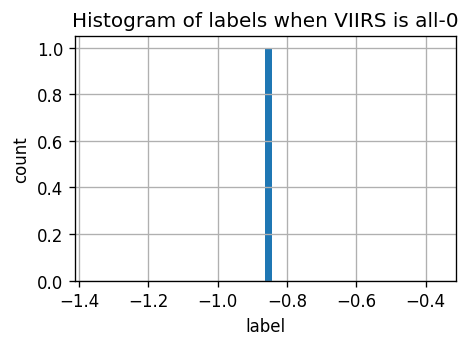

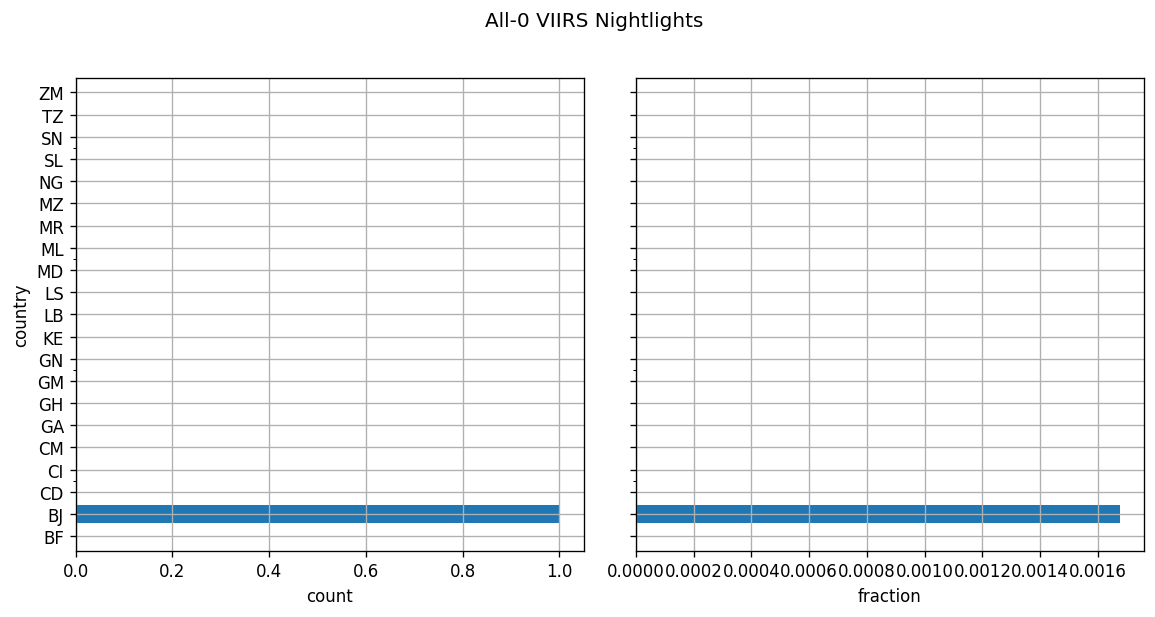

In [ ]:
# ================================================
# 7) All-Zero VIIRS NL check
# Detects "true zeros" using the observed minimum VIIRS value.
# ================================================
# If you have MEANS/STD_DEVS per dataset, plug them here to reproduce exact normalized zeros.

# Ensure mask exists (all VIIRS)
viirs_mask = np.ones(len(df), dtype=bool)

VIIRS_ZERO = float(df.loc[viirs_mask, 'nl_mean'].min())

zeros_df = pd.DataFrame(
    {
        'VIIRS': [
            VIIRS_ZERO,
            df.loc[viirs_mask, 'nl_center'].min(),
            df.loc[viirs_mask, 'nl_mean'].min(),
        ],
    },
    index=['True 0', 'min nls_center', 'min nls_mean']
)

with pd.option_context('display.precision', 9):
    display(zeros_df)

# Mask where VIIRS mean equals its minimum
viirs_zero_mask = viirs_mask & (df['nl_mean'].values == VIIRS_ZERO)

# Wealth distribution where VIIRS NL == 0
zeros_label_df = pd.DataFrame(
    {'label, when VIIRS is all-zero': df['wealthpooled'].values[viirs_zero_mask]}
)
display(zeros_label_df.describe().T)

# Histogram of wealth under all-zero VIIRS
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.hist(df['wealthpooled'].values[viirs_zero_mask], bins=50)
ax.set(xlabel='label', ylabel='count', title='Histogram of labels when VIIRS is all-0')
ax.grid(True)
plt.tight_layout()

# Per-country zero counts and fractions
df['zero_nl_viirs'] = viirs_zero_mask
zero_nl_counts = df.groupby('country')['zero_nl_viirs'].sum().astype(int)
zero_nl_frac   = zero_nl_counts / df.groupby('country').size()

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 5))
zero_nl_counts.plot.barh(width=0.8, ax=axs[0], grid=True)
zero_nl_frac.plot.barh(width=0.8, ax=axs[1], grid=True)
axs[0].set_xlabel('count')
axs[1].set_xlabel('fraction')
fig.suptitle('All-0 VIIRS Nightlights', y=1.02)
fig.tight_layout()

Index TFRecords:   0%|          | 0/819 [00:00<?, ?it/s]

1-th highest wealth: 3.747965, loc = CD 2023 (-5.521116, 13.565039)


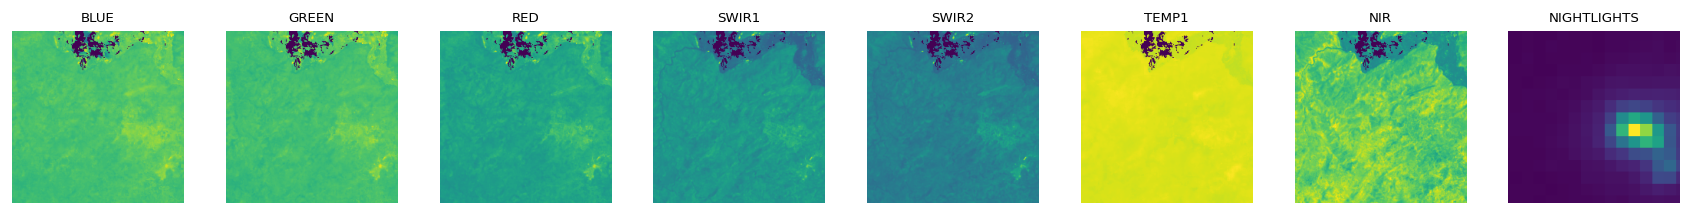

2-th highest wealth: 3.290847, loc = CD 2023 (-4.348062, 15.284118)


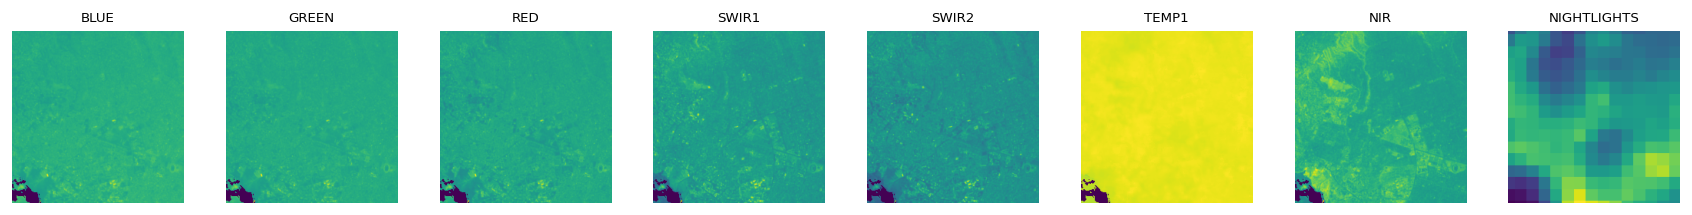

3-th highest wealth: 3.173927, loc = CD 2023 (-4.389954, 15.344676)


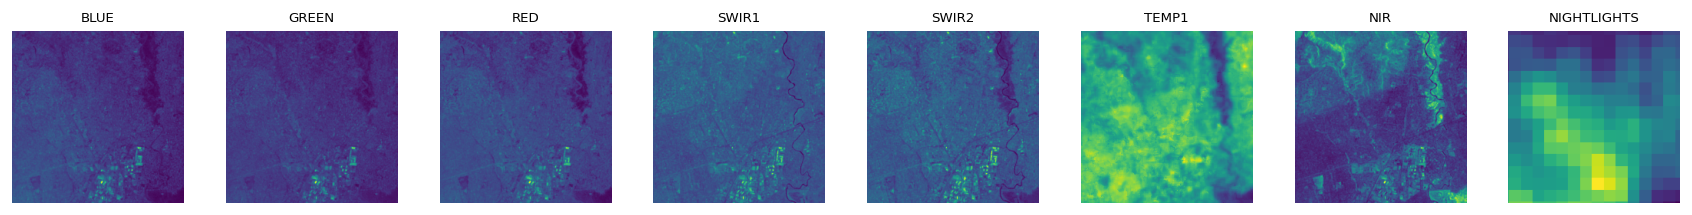

4-th highest wealth: 3.125668, loc = CD 2023 (-4.414685, 15.365917)


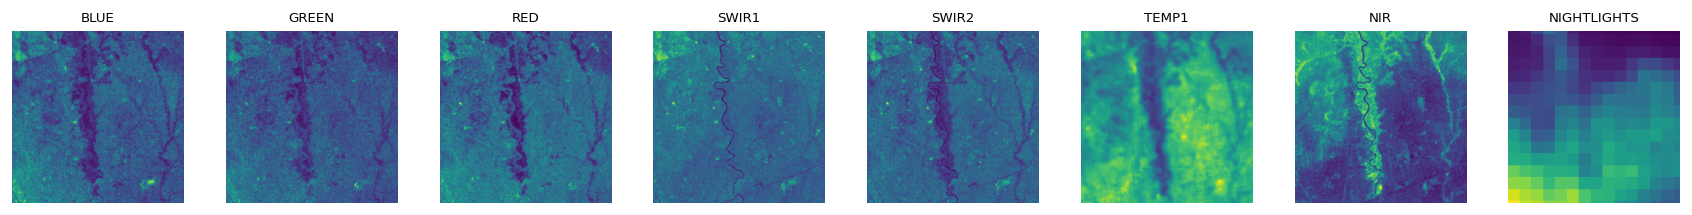

5-th highest wealth: 3.051698, loc = CD 2023 (-4.345835, 15.326164)


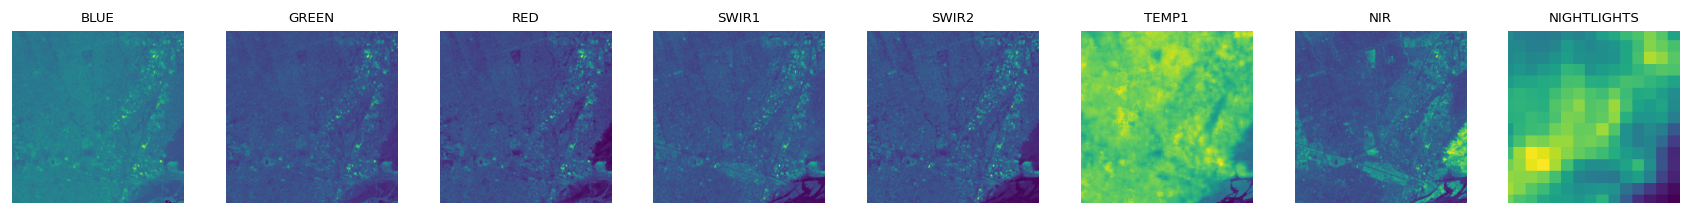

1-th lowest wealth: -1.916151, loc = GA 2020 (-3.214128, 11.094281)


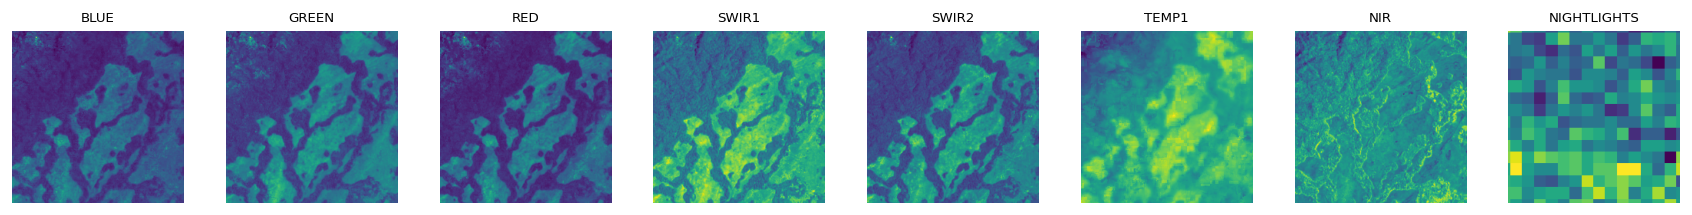

2-th lowest wealth: -1.818429, loc = GA 2021 (-1.229380, 12.068165)


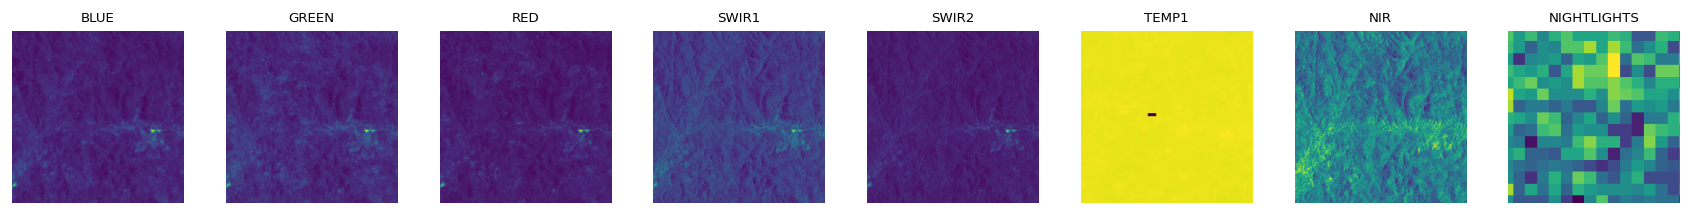

3-th lowest wealth: -1.802736, loc = GA 2021 (-1.285874, 12.253370)


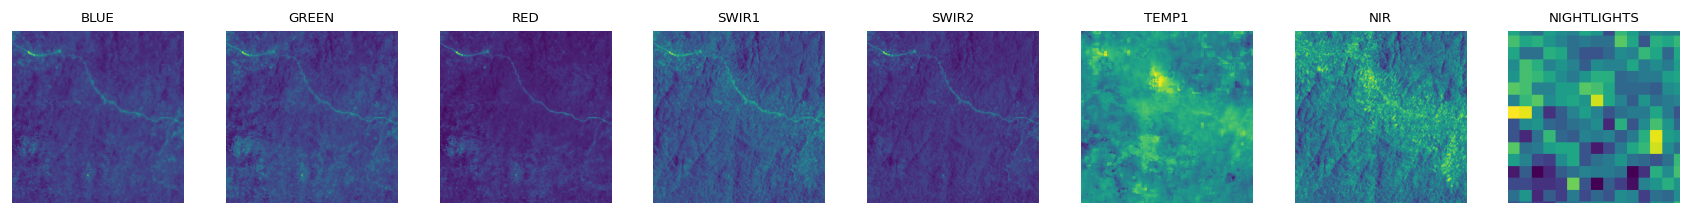

4-th lowest wealth: -1.797914, loc = GA 2020 (-3.100264, 10.669535)


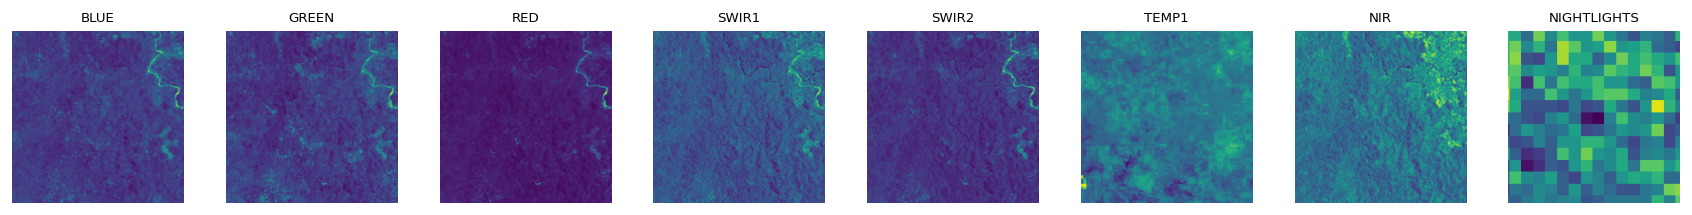

5-th lowest wealth: -1.735871, loc = GA 2020 (0.674880, 14.246267)


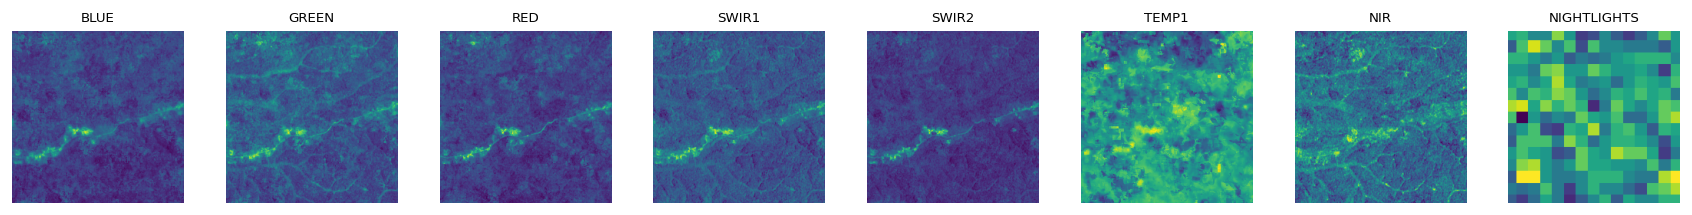

In [ ]:
# ================================================
# 8) Visualize Images (per-band panels) — robust key→path lookup
# 8.1) Highest wealth; 8.2) Lowest wealth
# Requires:
#  - df: combined DataFrame (lat,lon,wealthpooled,country,year,urban,nl_mean,nl_center,households)
#  - LOC_DICT_PATH: pickle from §2.1 with entries keyed by (country, year, cluster)
#  - TFRECORD_GLOB: pattern for TFRecord files (e.g., "gs://ssadata/*.tfrecord.gz")
#  - BANDS_ALL, BAND_ORDER, PATCH, CROP, SCALE_M, etc.
# Produces exact per-band panels like Yeh et al.
# ================================================
import os, re, math, pickle
import numpy as np, pandas as pd, tensorflow as tf
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ---------- 0) Load loc_dict and attach cluster + tf_year to df ----------
with tf.io.gfile.GFile(LOC_DICT_PATH, "rb") as f:
    loc_dict = pickle.load(f)

# loc_dict is keyed by (CC, year, cluster); values include lat, lon, svyid_year, year (calendar)
ldf = pd.DataFrame(
    [{"country":k[0], "tf_year":k[1], "cluster":k[2], **v} for k,v in loc_dict.items()]
)
# Join on (lat, lon, svyid_year == df['year']) to recover cluster and tf_year for each row
ldf_key = ldf[["lat","lon","svyid_year","cluster","tf_year"]].copy()
ldf_key["lat"]  = ldf_key["lat"].astype(float)
ldf_key["lon"]  = ldf_key["lon"].astype(float)
ldf_key["svyid_year"] = ldf_key["svyid_year"].astype(int)

df_aug = df.copy()
df_aug["lat"]  = df_aug["lat"].astype(float)
df_aug["lon"]  = df_aug["lon"].astype(float)
df_aug["year"] = df_aug["year"].astype(int)          # df.year is surveyID year
merged_df = df_aug.merge(
    ldf_key, left_on=["lat","lon","year"], right_on=["lat","lon","svyid_year"],
    how="left", validate="one_to_one"
)
if merged_df["cluster"].isna().any():
    nmiss = int(merged_df["cluster"].isna().sum())
    raise AssertionError(f"{nmiss} rows could not be matched to cluster/tf_year via (lat,lon,svyid_year).")

# Now we have: merged_df columns include country (CC), tf_year (calendar), cluster
# Build an identifier used in TFRecords
merged_df["tf_key"] = list(zip(merged_df["country"].astype(str),
                               merged_df["tf_year"].astype(int),
                               merged_df["cluster"].astype(int)))

# ---------- 1) Build or load a key→path cache over TFRecords ----------
KEYMAP_PKL = "/content/tfrecord_key_to_path.pkl"

def iter_examples_tfrecord(path):
    ds = tf.data.TFRecordDataset(path, compression_type="GZIP")
    for raw in ds.as_numpy_iterator():
        yield tf.train.Example.FromString(raw)

def _as_int(f, k):
    if k in f and f[k].int64_list.value:
        return int(f[k].int64_list.value[0])
    if k in f and f[k].float_list.value:
        return int(f[k].float_list.value[0])
    return None

def _as_str(f, k):
    if k in f and f[k].bytes_list.value:
        return f[k].bytes_list.value[0].decode("utf-8")
    return None

def build_keymap(glob_pat):
    key_to_path = {}
    file_paths = sorted(tf.io.gfile.glob(glob_pat))
    assert file_paths, f"No TFRecords match: {glob_pat}"
    for p in tqdm(file_paths, desc="Index TFRecords"):
        for ex in iter_examples_tfrecord(p):
            f = ex.features.feature
            cc  = (_as_str(f,"country") or "").upper()[:2]
            yr  = _as_int(f,"year")
            clu = _as_int(f,"cluster_index") if "cluster_index" in f else _as_int(f,"cluster")
            if not cc or yr is None or clu is None:
                continue
            key = (cc, int(yr), int(clu))
            # one-to-one expected; if dup appears, first wins
            key_to_path.setdefault(key, p)
    return key_to_path

if tf.io.gfile.exists(KEYMAP_PKL):
    with tf.io.gfile.GFile(KEYMAP_PKL, "rb") as f:
        key_to_path = pickle.load(f)
else:
    key_to_path = build_keymap(TFRECORD_GLOB)
    with tf.io.gfile.GFile(KEYMAP_PKL, "wb") as f:
        pickle.dump(key_to_path, f)

# Sanity: coverage
miss_keys = sum(k not in key_to_path for k in merged_df["tf_key"])
if miss_keys:
    print(f"WARNING: {miss_keys} df rows have no TFRecord path in keymap")

# ---------- 2) Utilities to read the exact example and extract bands ----------
def _as_arr(f, k):
    return np.asarray(f[k].float_list.value, dtype=np.float32) if k in f else None

def _center_crop(arr, patch=PATCH, crop=CROP):
    if arr is None or arr.size != patch*patch:
        return None
    z = arr.reshape(patch, patch)
    s = (patch - crop) // 2
    return z[s:s+crop, s:s+crop].ravel()

def fetch_image_for_key(key):
    """
    key = (country_2l, tf_year, cluster)
    returns (CROP, CROP, len(BANDS_ALL)) or None if not found.
    """
    if key not in key_to_path:
      return None
    p = key_to_path[key]
    for ex in iter_examples_tfrecord(p):
        f = ex.features.feature
        cc  = (_as_str(f,"country") or "").upper()[:2]
        yr  = _as_int(f,"year")
        clu = _as_int(f,"cluster_index") if "cluster_index" in f else _as_int(f,"cluster")
        if (cc, int(yr), int(clu)) != key:
            continue
        chans = []
        for b in BANDS_ALL:
            a = _as_arr(f, b)
            a = _center_crop(a, patch=PATCH, crop=CROP)
            if a is None:
                chans.append(np.zeros((CROP*CROP,), dtype=np.float32))
            else:
                chans.append(a)
        arr = np.stack(chans, axis=-1).reshape(CROP, CROP, len(BANDS_ALL))
        return arr
    return None

def plot_image_by_band(img, band_order, nrows=1, title=None):
    k = len(band_order)
    ncols = k if nrows==1 else int(math.ceil(k/nrows))
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.8*ncols, 1.8*nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, b in enumerate(band_order):
        chan = img[:, :, BANDS_ALL.index(b)]
        axes[i].imshow(chan)
        axes[i].set_title(b, fontsize=8)
        axes[i].axis('off')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    if title: fig.suptitle(title)
    fig.tight_layout()
    plt.show()

def plot_images_by_rows(row_indices, title_fmt):
    for k, ridx in enumerate(row_indices, start=1):
        r = merged_df.iloc[int(ridx)]
        key = (str(r["country"]), int(r["tf_year"]), int(r["cluster"]))
        img = fetch_image_for_key(key)
        if img is None:
            print(f"[skip] {key} not found in TFRecords")
            continue
        bo = list(BAND_ORDER)              # e.g., ['BLUE','GREEN','RED','SWIR1','SWIR2','TEMP1','NIR','NIGHTLIGHTS']
        title = title_fmt.format(
            k=k, label=r["wealthpooled"], country=r["country"],
            year=int(r["tf_year"]), lat=float(r["lat"]), lon=float(r["lon"])
        )
        print(title)
        plot_image_by_band(img, bo, nrows=1, title=None)

# ---------- 3) Select by wealth and plot ----------
labels = merged_df["wealthpooled"].values
years  = merged_df["tf_year"].values
locs   = merged_df[["lat","lon"]].values

K = 5

# Highest wealth
top_rows = np.argsort(labels)[::-1][:K]
plot_images_by_rows(
    top_rows,
    title_fmt="{k}-th highest wealth: {label:.06f}, loc = {country} {year} ({lat:.06f}, {lon:.06f})"
)

# Lowest wealth
low_rows = np.argsort(labels)[:K]
plot_images_by_rows(
    low_rows,
    title_fmt="{k}-th lowest wealth: {label:.06f}, loc = {country} {year} ({lat:.06f}, {lon:.06f})"
)